## Advanced cost analysis with hyperparameters (FL)
We evaluate FL costs under different **local epochs** and **client selection rates**.
For each setting, we show communication cost, training time, and accuracy.


### Imports

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Paths and load metrics

In [2]:
cwd = Path.cwd()
base = cwd / 'runs'

def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')

def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None

def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])


def comm_to_mb(comm_df):
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / (1024**2)

def comm_to_kb(comm_df):
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / 1024




### Selected client ratio

Modify `eligible_perc` in the exp-non-iid.yaml to change the client ratio. 

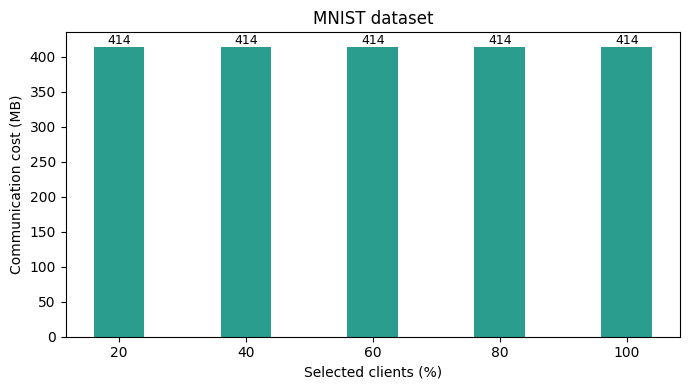

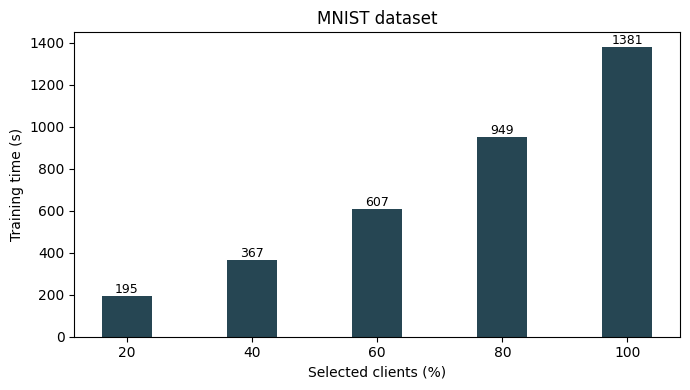

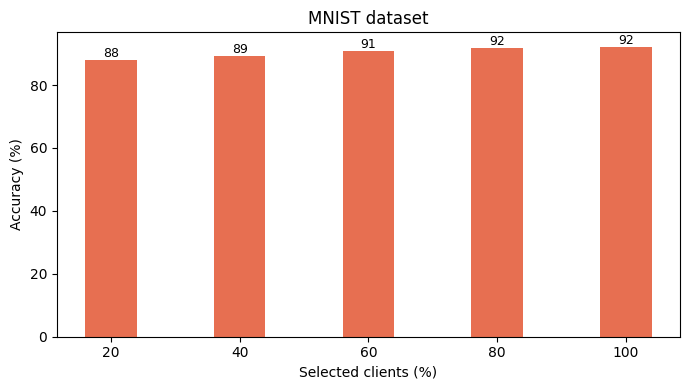

In [4]:
client_paths = {
    20: base / 'fluke_mnist_non_iid_client_ratio_20',
    40: base / 'fluke_mnist_non_iid_client_ratio_40',
    60: base / 'fluke_mnist_non_iid_client_ratio_60',
    80: base / 'fluke_mnist_non_iid_client_ratio_80',
    100: base / 'fluke_mnist_non_iid_client_ratio_100',
}

cl_comm = {}
cl_time = {}
cl_acc = {}
for k, path in client_paths.items():
    comm_df = load_comm_costs(path)
    cl_comm[k] = comm_to_mb(comm_df)
    cl_time[k] = load_run_time(path) or 0
    metrics_df = load_global_metrics(path)
    cl_acc[k] = float(metrics_df['accuracy'].iloc[-1]) * 100

x = sorted(client_paths.keys())

plt.figure(figsize=(7, 4))
bars = plt.bar([str(v) for v in x], [cl_comm[v] for v in x], color='#2A9D8F', width=0.4)
plt.title('MNIST dataset')
plt.xlabel('Selected clients (%)')
plt.ylabel('Communication cost (MB)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/new/mnist_clients_ratio_comm.png')
plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar([str(v) for v in x], [cl_time[v] for v in x], color='#264653', width=0.4)
plt.title('MNIST dataset')
plt.xlabel('Selected clients (%)')
plt.ylabel('Training time (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/new/mnist_clients_ratio_time.png')
plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar([str(v) for v in x], [cl_acc[v] for v in x], color='#E76F51', width=0.4)
plt.title('MNIST dataset')
plt.xlabel('Selected clients (%)')
plt.ylabel('Accuracy (%)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/new/mnist_clients_ratio_acc.png')
plt.show()



### Local epochs

Modify `local_epochs` in the fedavg.yaml to change the local epochs of each client. 

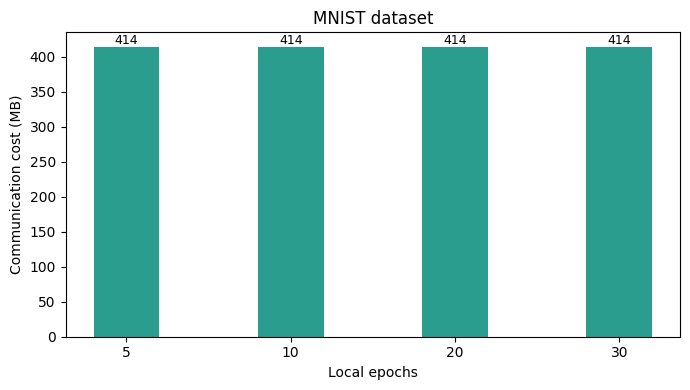

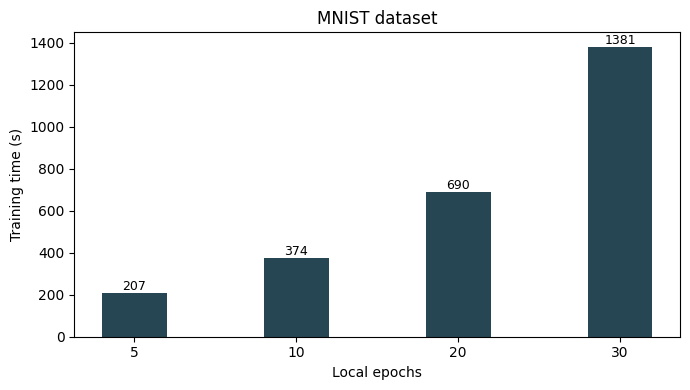

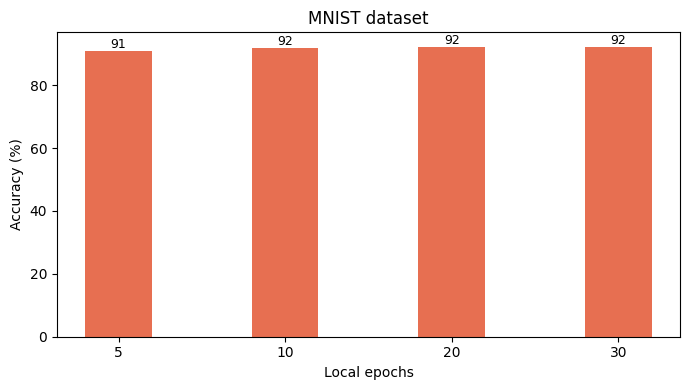

In [6]:
lep_paths = {
    5: base / 'fluke_mnist_non_iid_local_epoch_5',
    10: base / 'fluke_mnist_non_iid_local_epoch_10',
    20: base / 'fluke_mnist_non_iid_local_epoch_20',
    30: base / 'fluke_mnist_non_iid_local_epoch_30',
}

lep_comm = {}
lep_time = {}
lep_acc = {}
for k, path in lep_paths.items():
    comm_df = load_comm_costs(path)
    lep_comm[k] = comm_to_mb(comm_df)
    lep_time[k] = load_run_time(path) or 0
    metrics_df = load_global_metrics(path)
    lep_acc[k] = float(metrics_df['accuracy'].iloc[-1]) * 100

x = sorted(lep_paths.keys())

plt.figure(figsize=(7, 4))
bars = plt.bar([str(v) for v in x], [lep_comm[v] for v in x], color='#2A9D8F', width=0.4)
plt.title('MNIST dataset')
plt.xlabel('Local epochs')
plt.ylabel('Communication cost (MB)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/new/mnist_local_epochs_comm.png')
plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar([str(v) for v in x], [lep_time[v] for v in x], color='#264653', width=0.4)
plt.title('MNIST dataset')
plt.xlabel('Local epochs')
plt.ylabel('Training time (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/new/mnist_local_epochs_time.png')
plt.show()

plt.figure(figsize=(7, 4))
bars = plt.bar([str(v) for v in x], [lep_acc[v] for v in x], color='#E76F51', width=0.4)
plt.title('MNIST dataset')
plt.xlabel('Local epochs')
plt.ylabel('Accuracy (%)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plots/new/mnist_local_epochs_acc.png')
plt.show()
